In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb
import os

In [2]:
archivos_logs = [
    "./20250701-envases.log",
    "./20250702-envases.log",
    "./20250703-envases.log",
    "./20250704-envases.log",
    "./20250705-envases.log"
]

archivo_csv = "logs_unificados.csv"

# Tamaño de chunk para procesamiento (ajusta según la RAM)
# 8GB RAM: usa 50000
# 16GB RAM: usa 100000
# 32GB RAM: usa 200000
chunksize = 50000

In [3]:
primer_chunk = True

if os.path.exists(archivo_csv):
    print("Logs unificados.")
else:
    for archivo in archivos_logs:
        for chunk in pd.read_json(archivo, lines=True, chunksize=chunksize):
            chunk.to_csv(
                archivo_csv,
                mode="w" if primer_chunk else "a",
                header=primer_chunk,
                index=False,
                encoding="utf-8"
            )
            primer_chunk = False
    print("Logs unificados correctamente.")

Logs unificados.


In [4]:
df_preview = pd.read_csv("./logs_unificados.csv", nrows=5)
print(df_preview)

                    tiempo  estado metodo  \
0  2025-07-01 00:51:00.136     400   POST   
1  2025-07-01 00:51:00.146     400   POST   
2  2025-07-01 00:51:00.157     400   POST   
3  2025-07-01 00:51:00.165     400   POST   
4  2025-07-01 00:51:00.174     400   POST   

                                              pedido        server  \
0  /L9h/v3/envases/grupo1/nombres/0000015883985e9...  L9h/25.2.1.1   
1  /L9h/v3/envases/grupo1/nombres/000001a3ab59eab...  L9h/25.2.1.1   
2  /L9h/v3/envases/grupo1/nombres/000001d0b47bfe4...  L9h/25.2.1.1   
3  /L9h/v3/envases/grupo1/nombres/000002315c4ee98...  L9h/25.2.1.1   
4  /L9h/v3/envases/grupo1/nombres/000002b99372d3d...  L9h/25.2.1.1   

             baliza  acceso  decode  detect  refine  assess  vector  search  \
0  f0a7427730a97df0     NaN     0.0     0.0     0.0       0     0.0       0   
1  bbc66ae28914cbb7     NaN     0.0     0.0     0.0       0     0.0       0   
2  17606c7517fce1e4     NaN     0.0     0.0     0.0       0     0.0    

In [5]:
if os.path.exists("logs_unificados.parquet"):
    print("Archivo Parquet listo.")
else:
    duckdb.sql("COPY (SELECT * FROM read_csv_auto('logs_unificados.csv',types = {'decode': 'VARCHAR'})) TO 'logs_unificados.parquet' (FORMAT 'parquet');")
    print("Archivo Parquet creado correctamente.")

Archivo Parquet listo.


## Uso de DuckDB
DuckDB es una base de datos analítica embebida que permite procesar archivos grandes sin cargarlos completamente en RAM. Se utilizó porque maneja mejor grandes volúmenes de datos que pandas con CSV, optimizando tiempo y memoria.

## Cambio al Parquet
La conversión al formato Parquet fue clave para poder trabajar con un volumen tan grande, ya que este formato es columnar, binario y comprimido. Esto reduce el uso de memoria, acelera las lecturas y permite realizar análisis estadísticos eficientes, sin cargar todo el dataset en la RAM.

In [6]:
df = pd.read_parquet("logs_unificados.parquet")

In [7]:
# Visualizar las primeras filas del DataFrame
df.head()

,tiempo,estado,metodo,pedido,server,baliza,acceso,decode,detect,refine,assess,vector,search,verify,commit,entire,envase,nombre,fuentes,rostros
0,2025-07-01 00:51:00.136,400,POST,/L9h/v3/envases/grupo1/nombres/0000015883985e9...,L9h/25.2.1.1,f0a7427730a97df0,None,0.0,0.0,0.0,0,0.0,0,0,0.0,0.530,grupo1,0000015883985e92a5be19bd0f1c138f_jpg,None,None
1,2025-07-01 00:51:00.146,400,POST,/L9h/v3/envases/grupo1/nombres/000001a3ab59eab...,L9h/25.2.1.1,bbc66ae28914cbb7,None,0.0,0.0,0.0,0,0.0,0,0,0.0,0.007,grupo1,000001a3ab59eabe4d5d5092369e69d6_jpg,None,None
2,2025-07-01 00:51:00.157,400,POST,/L9h/v3/envases/grupo1/nombres/000001d0b47bfe4...,L9h/25.2.1.1,17606c7517fce1e4,None,0.0,0.0,0.0,0,0.0,0,0,0.0,0.007,grupo1,000001d0b47bfe424cef95a1acbd0740_jpg,None,None
3,2025-07-01 00:51:00.165,400,POST,/L9h/v3/envases/grupo1/nombres/000002315c4ee98...,L9h/25.2.1.1,0dde0b665eee00f6,None,0.0,0.0,0.0,0,0.0,0,0,0.0,0.006,grupo1,000002315c4ee98bb2d8096ef5c484e7_jpg,None,None
4,2025-07-01 00:51:00.174,400,POST,/L9h/v3/envases/grupo1/nombres/000002b99372d3d...,L9h/25.2.1.1,bef971e6e1cf6063,None,0.0,0.0,0.0,0,0.0,0,0,0.0,0.006,grupo1,000002b99372d3d7f31c398a6427e8a3_jpg,None,None


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000194 entries, 0 to 16000193
Data columns (total 20 columns):
 #   Column   Dtype         
---  ------   -----         
 0   tiempo   datetime64[us]
 1   estado   int64         
 2   metodo   object        
 3   pedido   object        
 4   server   object        
 5   baliza   object        
 6   acceso   object        
 7   decode   object        
 8   detect   float64       
 9   refine   float64       
 10  assess   int64         
 11  vector   float64       
 12  search   int64         
 13  verify   int64         
 14  commit   float64       
 15  entire   float64       
 16  envase   object        
 17  nombre   object        
 18  fuentes  object        
 19  rostros  object        
dtypes: datetime64[us](1), float64(5), int64(4), object(10)
memory usage: 2.4+ GB


In [9]:
df.describe()

,tiempo,estado,detect,refine,assess,vector,search,verify,commit,entire
count,16000194,1.600019e+07,1.600019e+07,1.600019e+07,1.600019e+07,1.600019e+07,1.600019e+07,16000194.0,1.600019e+07,1.600019e+07
mean,2025-07-02 21:28:35.456432,2.010786e+02,7.396079e-01,1.279909e+01,1.379267e+00,7.761490e-02,1.862968e+01,0.0,6.422012e-02,4.364060e+01
min,2025-07-01 00:51:00.136000,2.010000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00
25%,2025-07-01 20:17:51.298750,2.010000e+02,4.000000e-01,6.261000e+00,1.000000e+00,0.000000e+00,1.000000e+01,0.0,0.000000e+00,1.007000e+01
50%,2025-07-02 18:59:34.978500,2.010000e+02,5.930000e-01,9.980000e+00,1.000000e+00,0.000000e+00,1.500000e+01,0.0,0.000000e+00,1.227600e+01
75%,2025-07-03 20:52:28.355250,2.010000e+02,8.480000e-01,1.622100e+01,1.000000e+00,0.000000e+00,2.300000e+01,0.0,0.000000e+00,2.943200e+01
max,2025-07-05 04:58:51.460000,4.220000e+02,4.316490e+02,1.264647e+03,2.820000e+02,3.267680e+02,4.640000e+02,0.0,9.771100e+02,1.420505e+04
std,NaN,4.159063e+00,1.355154e+00,9.786506e+00,1.328070e+00,1.667224e+00,1.249048e+01,0.0,2.091687e+00,8.319936e+01


In [10]:
tabla_metodo = df['metodo'].value_counts()
print(tabla_metodo)

metodo
POST    16000194
Name: count, dtype: int64


In [11]:
# Columnas numéricas importantes para analizarse en estadística
columnas_numericas = ["detect", "refine", "assess", "commit", "entire", "vector", "search", "verify"]

In [12]:
con = duckdb.connect()

# Registrar el DataFrame como tabla
con.register("df", df)

# Registrar estadísticas descriptivas para cada columna numérica
consultas = []

for col in columnas_numericas:
    consultas.append(f"""
        SELECT
            '{col}' AS columna,
            AVG(TRY_CAST({col} AS DOUBLE)) AS media,
            STDDEV(TRY_CAST({col} AS DOUBLE)) AS desviacion_estandar,
            VAR_POP(TRY_CAST({col} AS DOUBLE)) AS varianza,
            MEDIAN(TRY_CAST({col} AS DOUBLE)) AS mediana,
            SKEWNESS(TRY_CAST({col} AS DOUBLE)) AS sesgo,
            KURTOSIS(TRY_CAST({col} AS DOUBLE)) AS curtosis
        FROM df
    """)

query = " UNION ALL ".join(consultas)

estadisticas = con.execute(query).df()
print(estadisticas)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  columna      media  desviacion_estandar     varianza  mediana      sesgo  \
0  detect   0.739608             1.355154     1.836441    0.593  34.785543   
1  refine  12.799092             9.786506    95.775702    9.980   3.115280   
2  assess   1.379267             1.328070     1.763769    1.000   4.496802   
3  commit   0.064220             2.091687     4.375155    0.000  85.472767   
4  entire  43.640597            83.199360  6922.133145   12.276  10.582697   
5  vector   0.077615             1.667224     2.779636    0.000  30.291313   
6  search  18.629684            12.490476   156.011971   15.000   2.672607   
7  verify   0.000000             0.000000     0.000000    0.000        NaN   

       curtosis  
0   2644.938692  
1     79.866957  
2    395.462084  
3  17384.425259  
4    647.764730  
5   1366.079685  
6     14.743236  
7           NaN  


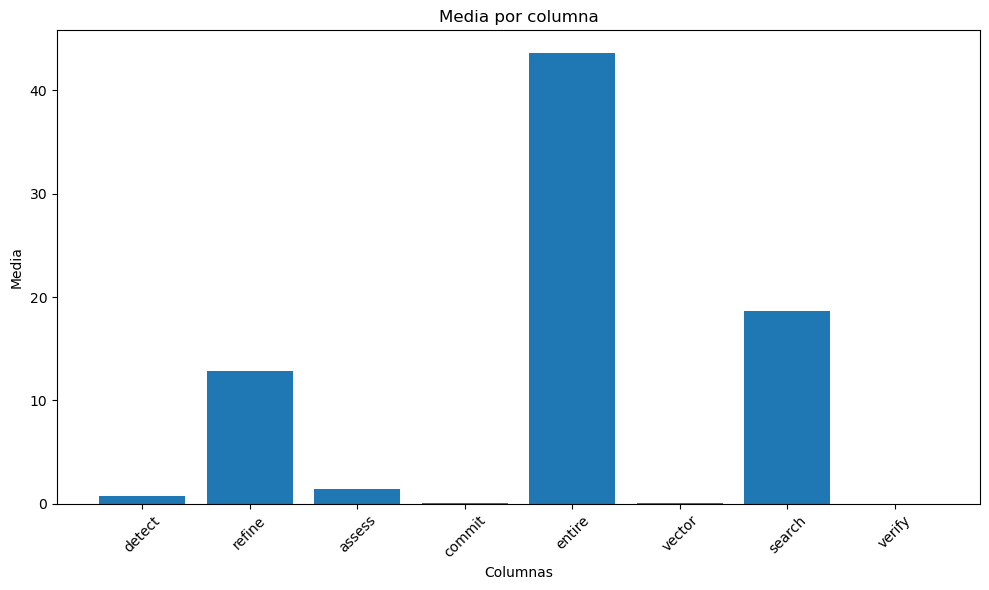

In [13]:
# Gráfica de barras (medias)
plt.figure(figsize=(10,6))
plt.bar(estadisticas["columna"], estadisticas["media"])
plt.title("Media por columna")
plt.xlabel("Columnas")
plt.ylabel("Media")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Gráfica de dispersión
plt.figure(figsize=(8,6))
plt.scatter(df["detect"], df["entire"], alpha=0.3)
plt.title("Relación entre detect y entire")
plt.xlabel("detect")
plt.ylabel("entire")
plt.show()